# Rapport Statistique desciptive

---

MEDJDKOUH Khaled, ing3 macs

RAZAFINDRAKOTO Davidson Lova, ing3 macs

---

# **1- INTRODUCTION/ AIM OF THE PAPER:**




Uncertainty refers to the lack of confidence (`Variability`) for each output of a machine learning algorithm. While it’s impossible to create an algorithm that has perfect certainty (i.e. I’m 100% sure this is a dog) we need to understand what generates uncertainty ? , how to quantify it ? , and how to reduce it ?

There are two sources of uncertainty that affect machine learning algorithms, epistemic and aleatoric: 

1.   Epistemic uncertainty refers to the model’s uncertainty due to the lack of training data
2.   aleatoric uncertainty refers to the inherent stochasticity of the observations, such as noise in the measurements.

Consequently, understanding if the model is indeed making accurate predictions or simply guessing at random is not trivial.

Bayesian machine learning seems to provide the solution, in the article, a new gradient-free training algorithm based on Approximate Bayesian Computation by Subset Simulation is proposed. In the proposed method, the likelihood function and the weights are defined by non-parametric formulations.

The experiments, specially the engineering case study on composite materials subject to fatigue damage, show the ability of the proposed algorithm to consistently reach accurate predictions while avoiding gradient related instabilities, and most importantly, it provides a realistic and coherent quantification of the uncertainty represented by confidence bounds.

[Little video tutorial on *How to handle Uncertainty in Deep Learning*](https://www.youtube.com/watch?v=p1EnIbDItTc)

# **2- BACKGROUND** ::



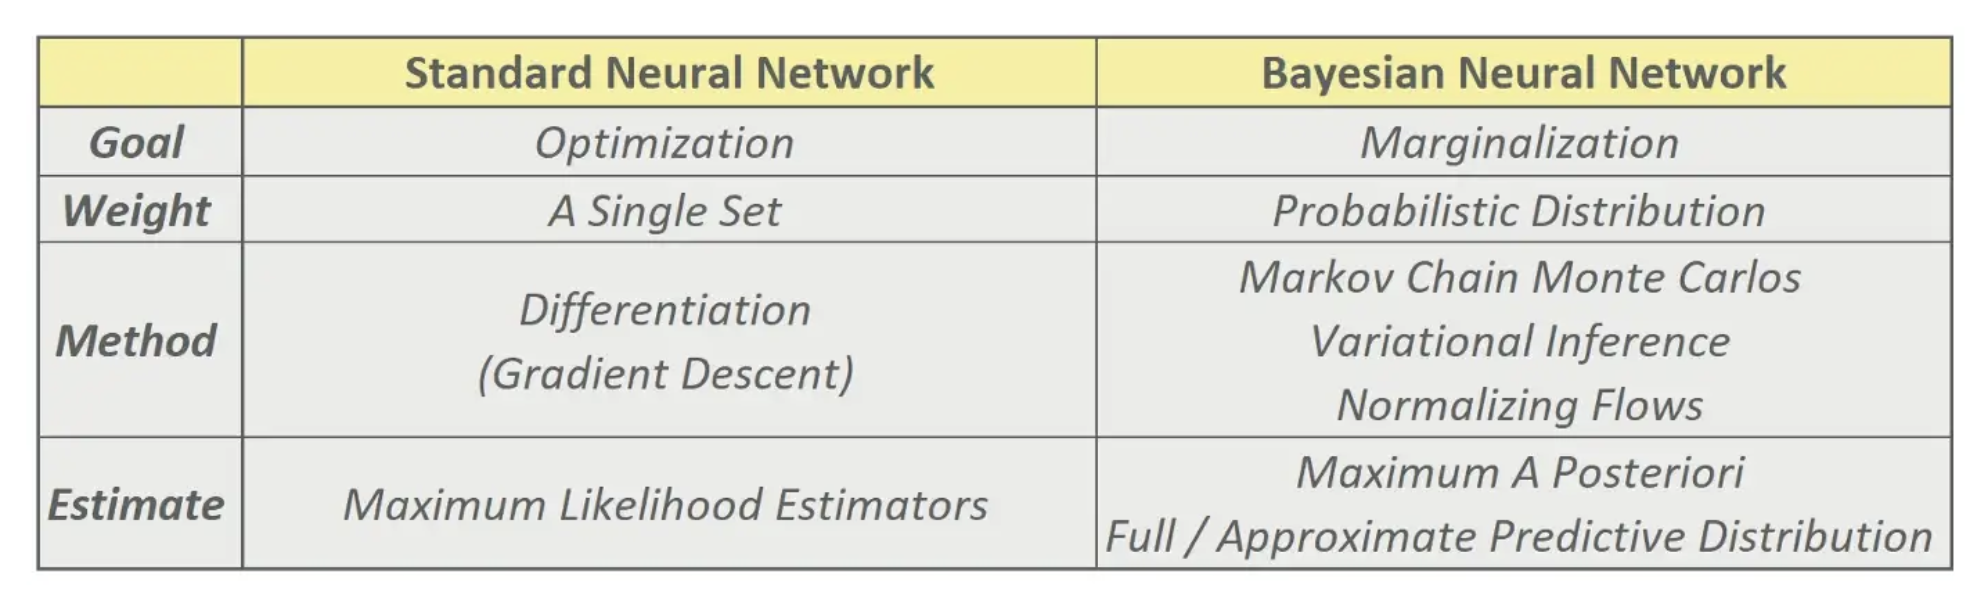

## 2.1 FNN ([Feedfoward Neural Network](https://en.wikipedia.org/wiki/Feedforward_neural_network))

## 2.2 BNN (Bayesian Neural Network)

Given a data set $D = (x,y) \in \mathcal{X} \times \mathcal{Y} \in \mathbb{R}^m \times \mathbb{R}^l$.

(Here we note that $(x,y)$ is taken a random variable that sumarise every possible couples $(x(\omega), y(\omega))$)

Let $\mathcal{M}$ be a model (here it is a FNN) with parameters $\theta = \{w ,b\}$ (où $w$ are the weights and $b$ the biais).

BNN consists at esmitimating the a posteriori distribition of $\theta$ assuming the model $\mathcal{M}$ and the data set $D$.

And $p(\theta |D , \mathcal{M})$ is the PDF of said distribution.

The standard way of estimating this distribition is to deduces by using Bayes' formula as such $p(\theta |D , \mathcal{M}) = \frac{p(D| \theta, \mathcal{M}) p(\theta|\mathcal{M})}{p(D|\mathcal{M})}$

* $p(\theta| D, \mathcal{M})$ : a posteriori distribution of $\theta$ <span style="color:red">to be estimated</span>
* $p(\theta|\mathcal{M})$ : a priori distributon of $\theta$ <span style="color:red"> given a the start</span>
* $p(D| \theta, \mathcal{M})$ : likelyhood function assuming the parameters $\theta$ and the model $ \mathcal{M}$ are known  <span style="color:red"> costly to estimate</span>
* $p(D|\mathcal{M})$ : Distribution the data assuming the model is known <span style="color:orange"> there are method that do not require it to be calculated</span>


## 2.3 Approximate Bayesian computation by subset simulation

* ### ABC ([Approximate Bayesian Computation](https://en.wikipedia.org/wiki/Approximate_Bayesian_computation))

  The ABC method consits at estimating $p(\theta |D , \mathcal{M})$ without evaluating the likelyhood fonction which can be costly.     

  Given $ \hat{y} = f(x, \theta)$ which comes from evaluating $x$ through the model $\mathcal{M}$(a feedforward pass) with $\theta \sim p(\theta, \mathcal{M})$.

  Bayes' formula gives $p( \theta, \hat{y} | D, \mathcal{M}) \propto p( D | \hat{y}, \theta, \mathcal{M})p( \hat{y}| \theta,\mathcal{M})p( \theta| \mathcal{M}) $

  We then simulate the distribution on the right hand side with the rejection method by similating $\theta \sim p(\theta |M)$, $\hat{y} \sim p( \hat{y}| \theta,\mathcal{M})$ and accept if and only if $y = \hat{y}$.

  Since the equality could be too harsh of a condition to meet (even impossible to meet), we introduce a tolerance $\epsilon$ and we replace it by the weaker condition $|y - \hat{y}| < \epsilon$ (the quality of which will depend on how small of a tolerance we take).

  We thus get  $p_{\epsilon} (\theta, \hat{y}| D, \mathcal{M}) \propto \mathbb{I}_{\mathcal{N}_\epsilon (D)} (\hat{y}) p( \hat{y}| \theta,\mathcal{M})p( \theta| \mathcal{M}) $ où $\mathcal{N}_\epsilon (D= (x,y)) = \left\{ \hat{y} \in \mathcal{Y}, \rho(\eta(y), \eta(\hat{y})) \leq \epsilon\right\} $

  With $\eta$ is a set of statistics that sumarize a distribution (for example a mean or a median) and $\rho$ is a dissimilarity measure.

  Integrating with respect to $\hat{y}$ gives :
    
  $p_{\epsilon}( \theta | D, \mathcal{M}) \propto \int_{\mathcal{Y}} p_{\epsilon}( \theta , \hat{y}| D, \mathcal{M}) d \hat{y} \propto \int_{\mathcal{Y}} \mathbb{I}_{\mathcal{N}_\epsilon (D)} (\hat{y}) p( \hat{y}| \theta,\mathcal{M}) p( \theta| \mathcal{M}) d \hat{y} = p( \theta| \mathcal{M}) \int_{\mathcal{Y}} \mathbb{I}_{\mathcal{N}_\epsilon (D)} (\hat{y})  p( \hat{y}| \theta,\mathcal{M}) d \hat{y} = \mathbb{P} (\hat{y} \in \mathcal{N}_{\epsilon} (D)| \theta, \mathcal{M}) p( \theta| \mathcal{M})$

  (for $\epsilon$ small enough, $p_{\epsilon}( \theta | D, \mathcal{M})$ will be close to $p( \theta | D, \mathcal{M})$)


A Naive implementation of the ABC method :

```Python
  thetas = []
y_hats = []
for n in range(Nmax) :
  while True
  theta = simuler_theta() # Simulate theta with it a priori distribution
  y_hat = generer_y(theta) # generate y_hat using the previously simulated theta with a forward pass of the FNN
  if((rho(eta(y_hat), eta(y))) <= epsilon) # if y_hat is close enough to y we keep it
      break
  # We collect the good cases to simulate their distribution
  thetas.append(theta)
  y_hats.append(theta)
```


* #### SS ([Subset Simulation](https://en.wikipedia.org/wiki/Subset_simulation))

  Since the rejection algorithm can take too long to get past the tolerance (in the `while` loop), we use subset simulation.


  The idea is that if the probality that we are trying to simulate is too low, it would take a substancial amount of tries to get there (that is the case here is ABC). 
  
  Subset simulation consists of writting the small probability into the product of bigger one, which are then in turns easier to simulate.

  One can write $\mathbb{P} (\hat{y} \in \mathcal{N}_{\epsilon} (D)| \theta, \mathcal{M}) = \mathbb{P} (\hat{y} \in \mathcal{N}_{\epsilon_1} (D)| \theta, \mathcal{M}) \prod_{i = 2}^m \mathbb{P} (\hat{y} \in \mathcal{N}_{\epsilon_j} (D)| \hat{y} \in \mathcal{N}_{\epsilon_{j-1}} (D), \theta, \mathcal{M})$ avec $ \epsilon = \epsilon_{1} <... < \epsilon_m$




  Implementation of ABC - SS

```Python
''' Let PO in [0,1] be given such that N*P0 and 1/PO are integers and N is the samples size per interation'''

## Generate initial samples
import numpy as np
thetas = [simuler_theta() for i in range(0, N)]
y_hats = [generer_y(X,theta) for theta in thetas]

for j in range(0, m) :

    ## Get the dissimilarities
    rho_n = []
    for n in range(0, N) :
        rho_n.append(np.linalg.norm(y_hat[n] - y))

    # reindexing with the first having the smallest rho_n and so on
    new_indices = list(np.argsort(rho_n))
    thetas = list(np.array(thetas)[new_indices])
    y_hats = list(np.array(y_hats)[new_indices])
    rho_n = list(np.array(rho_n)[new_indices])

    # Calculating the tolerance
    epsilon_j = (rho_n[int(N*P0)] + rho_n[int(N*P0) + 1])/2

    # Generating new samples from the N*PO that were the most similar to y
    new_thetas = []
    new_y_hats = []
    for k in range(0, int(N*P0)) : 
        t1, t2  = MMA(nb_samples = int(1/P0),seed_theta = thetas[k], tol = epsilon_j, X = X,y = y)

        new_thetas += t1
        new_y_hats += t2

    thetas = new_thetas
    y_hats = new_y_hats
    
    # Stop when we get past the original tolerance
    if epsilon_j <= epsilon :
        break     
```

# **3- Training BNN By ABC-Sub**


## 3.1 Proposed Methodology

First choose a sample size $N$, $p_0 \in [0,1]$ such that $p_0\times N$ and $p_0^{-1} \in \mathbb{Z}^*$

1.  Generate $N$ samples of $\theta = {w,b}$ from it's prior user defined PDF $p(\theta|\mathcal{M})$ (in this cas $\mathcal{N}(0,1)$)

2.  Use them to run a forward pass and obtain $N$ outputs $\hat{y}(\theta)$.

3.  Evaluate the metric $\rho(\eta(\hat{y}), \eta(y))$ for each sample ${\theta, \hat{y}(\theta)}$.

4.  Keep $p_0\times N$ $\theta$ with the lowest metric value $\rho$ as seeds.

5.  These seeds are used to:

    *   automatically fix the tolerance value $\epsilon_j$, as the highest metric value $\rho$ among the seeds.
    *   obtain $p_0^{-1}$ new samples from each seed verifying $\rho \leq \epsilon_j$ using the **Modified
Metropolis Algorithm (MMA)**

6. repeat the process until $\epsilon_j \leq \epsilon$, whereby $p_{\epsilon}( \theta | D, \mathcal{M})$ is approximated



Note that : 

*   The distribution of parameters in the final subset constitute the marginalized posterior $p_{\epsilon}( \theta | D, \mathcal{M})$ whose information is used to produce robust predictions and quantify their uncertainty
*   To make sure to acheive the wanted tolerance, replace the for loop by a while loop (in the given algorithm), so instead of specifying the number of simulations levels to be carried out, the algorithm performs as many simulations levels as needed to reach the desired tolerance value $\epsilon$


## 3.2 Illustrative Problem 1

The aim is to estimate the value of $cos(x)$ from noised data.

Note that : 

* Training data is generated from the cosenoidal function $y = cos(x) + \zeta$, where $\zeta \sim \mathcal{N}(0,1)$

* The domain of the training inputs $x$ is uniformly distributed over the interval $[−3,3]$.
* The training data set comprises a single batch of 200 samples with no preprocessing.
* The architecture of the BNN : 

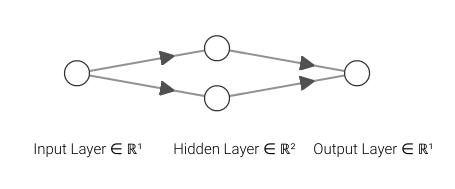

  * The activation function used for both the hidden and output layers is the hyperbolic tangent
  * The hyper-parameters chosen are: $p_0 = 0.2, N = 5000, l = 6$
  * Mean Squared Error (MSE) as metric $\rho$

The same training data has been used to fit a conventional FNN with the same architecture, and trained with a batch gradient descent algorithm (learning rate (`lr = 0.001`)  and `epochs = 10000`), for reference purposes.



We notice that :      

* Predictions from BNN by ABC-SS consistently reached similar
outcomes, while those from the FNN, experience more variability
* BNN by ABC-SS provides
an accurate quantification of the uncertainty in its predictions.


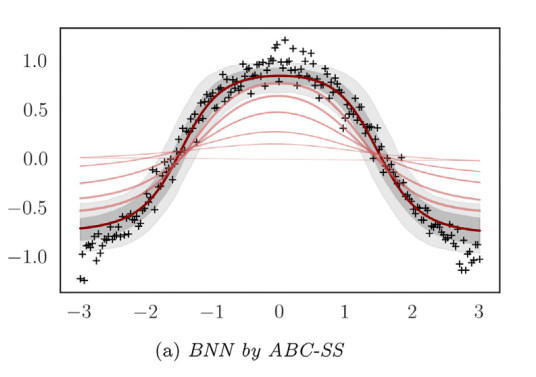

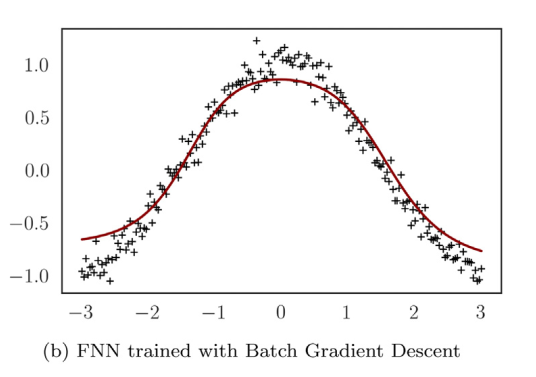

## 3.3 Illustrative Problem 2

<img src="photo/FNN_3.png" /> 

# **4- ENGINEERING CASE STUDY -Fatigue Damage in composite materials-**

BLA BLA

## 4.1 Description of the case study

## 4.2 Baseline algorithms

The model is the FNN drawn bellow.
<img src="photo/FNN_4.png" /> 

*   ABC-SS methods $p_0 = 0.1, N = 10^6, \sigma_0 = 0.75, p = 0.58, \epsilon = 0.012$
*   Variational Inference, Bayes by Backprop (BPP)
$\sigma_1 = 1.5, \sigma_2 = 0.1, \pi = 0.5,$ Adam optimizer, $lr = 0.001$ and $epochs = 10^6$, same FNN with `LeakyRelU`
*   Probabilistic Backpropagation (PBP)
*   Hamiltonian Monte Carlo, $\epsilon = 0.001, L = 10$


## 4.3 Performance metric

## 4.4 Application of BNN by ABC-SS 

## 4.5 Comparison with the state-of-the-art BNN

# **5- DISCUSSION / CONCLUSION**
